# Lung Cancer Classification
---

### Importing Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np
import math

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.datasets import make_classification

# Data modeling libraries
from xgboost import XGBClassifier as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Model evaluation library
from sklearn.metrics import confusion_matrix, classification_report

### Reading the Data

In [2]:
# Read the data
df = pd.read_csv("../data/raw/dataset1.csv", engine="pyarrow")
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


### Initial Data Profiling
We will:
1. Check the dataset brief information (data types of each feature, what does each features represents)
2. Dataset briefly statistical information
3. Check for missing values

In [3]:
# Check the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   GENDER                 309 non-null    str  
 1   AGE                    309 non-null    int64
 2   SMOKING                309 non-null    int64
 3   YELLOW_FINGERS         309 non-null    int64
 4   ANXIETY                309 non-null    int64
 5   PEER_PRESSURE          309 non-null    int64
 6   CHRONIC DISEASE        309 non-null    int64
 7   FATIGUE                309 non-null    int64
 8   ALLERGY                309 non-null    int64
 9   WHEEZING               309 non-null    int64
 10  ALCOHOL CONSUMING      309 non-null    int64
 11  COUGHING               309 non-null    int64
 12  SHORTNESS OF BREATH    309 non-null    int64
 13  SWALLOWING DIFFICULTY  309 non-null    int64
 14  CHEST PAIN             309 non-null    int64
 15  LUNG_CANCER            309 non-null    str  
dtypes

In [4]:
for i in df.columns:
    print(f"{i}: {df[i].unique()}")

GENDER: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
AGE: [69 74 59 63 75 52 51 68 53 61 72 60 58 48 57 44 64 21 65 55 62 56 67 77
 70 54 49 73 47 71 66 76 78 81 79 38 39 87 46]
SMOKING: [1 2]
YELLOW_FINGERS: [2 1]
ANXIETY: [2 1]
PEER_PRESSURE: [1 2]
CHRONIC DISEASE: [1 2]
FATIGUE : [2 1]
ALLERGY : [1 2]
WHEEZING: [2 1]
ALCOHOL CONSUMING: [2 1]
COUGHING: [2 1]
SHORTNESS OF BREATH: [2 1]
SWALLOWING DIFFICULTY: [2 1]
CHEST PAIN: [2 1]
LUNG_CANCER: <ArrowStringArray>
['YES', 'NO']
Length: 2, dtype: str


**About Dataset**
This dataset consists of 3.000 rows and 16 features.

**Data Fields**
1. GENDER: Gender of the patient (M for Male, F for Female)
2. AGE: Age of the patient in years
3. SMOKING: Indicates smoking status (2 for Yes, 1 for No)
4. YELLOW_FINGERS: Indicates presence of yellow fingers (2 for Yes, 1 for No)
5. ANXIETY: Indicates presence of anxiety (2 for Yes, 1 for No)
6. PEER_PRESSURE: Indicates level of peer pressure experienced by the patient (1 for No, 2 for Yes)
7. CHRONIC_DISEASE: Indicates presence of chronic diseases (1 for No, 2 for Yes)
8. FATIGUE: Indicates presence of fatigue (1 for No, 2 for Yes)
9. ALLERGY: Indicates presence of allergies (1 for No, 2 for Yes)
10. WHEEZING: Indicates presence of wheezing (1 for No, 2 for Yes)
11. ALCOHOL_CONSUMING: Indicates alcohol consumption status (1 for No, 2 for Yes)
12. COUGHING: Indicates presence of coughing (1 for No, 2 for Yes)
13. SHORTNESS_OF_BREATH: Indicates presence of shortness of breath (1 for No, 2 for Yes)
14. SWALLOWING_DIFFICULTY: Indicates presence of swallowing difficulty (1 for No, 2 for Yes)
15. CHEST_PAIN: Indicates presence of chest pain (1 for No, 2 for Yes)
16. LUNG_CANCER: Indicates the diagnosis of lung cancer (YES for diagnosed, NO for not diagnosed)

In [5]:
# Check the distribution of the dataset
df.describe().T # Transpose

,count,mean,std,min,25%,50%,75%,max
AGE,309.0,62.673139,8.210301,21.0,57.0,62.0,69.0,87.0
SMOKING,309.0,1.563107,0.496806,1.0,1.0,2.0,2.0,2.0
YELLOW_FINGERS,309.0,1.569579,0.495938,1.0,1.0,2.0,2.0,2.0
ANXIETY,309.0,1.498382,0.500808,1.0,1.0,1.0,2.0,2.0
PEER_PRESSURE,309.0,1.501618,0.500808,1.0,1.0,2.0,2.0,2.0
CHRONIC DISEASE,309.0,1.504854,0.500787,1.0,1.0,2.0,2.0,2.0
FATIGUE,309.0,1.673139,0.469827,1.0,1.0,2.0,2.0,2.0
ALLERGY,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
WHEEZING,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0
ALCOHOL CONSUMING,309.0,1.556634,0.497588,1.0,1.0,2.0,2.0,2.0


In [6]:
# Check for missing values
df.isna().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

In [7]:
# Check for duplicate
df.duplicated().sum()

np.int64(33)

There are no missing values on the dataset, therefore no need missing values handling.

### Exploratory Data Analysis (EDA)
We will check the distribution of each features.

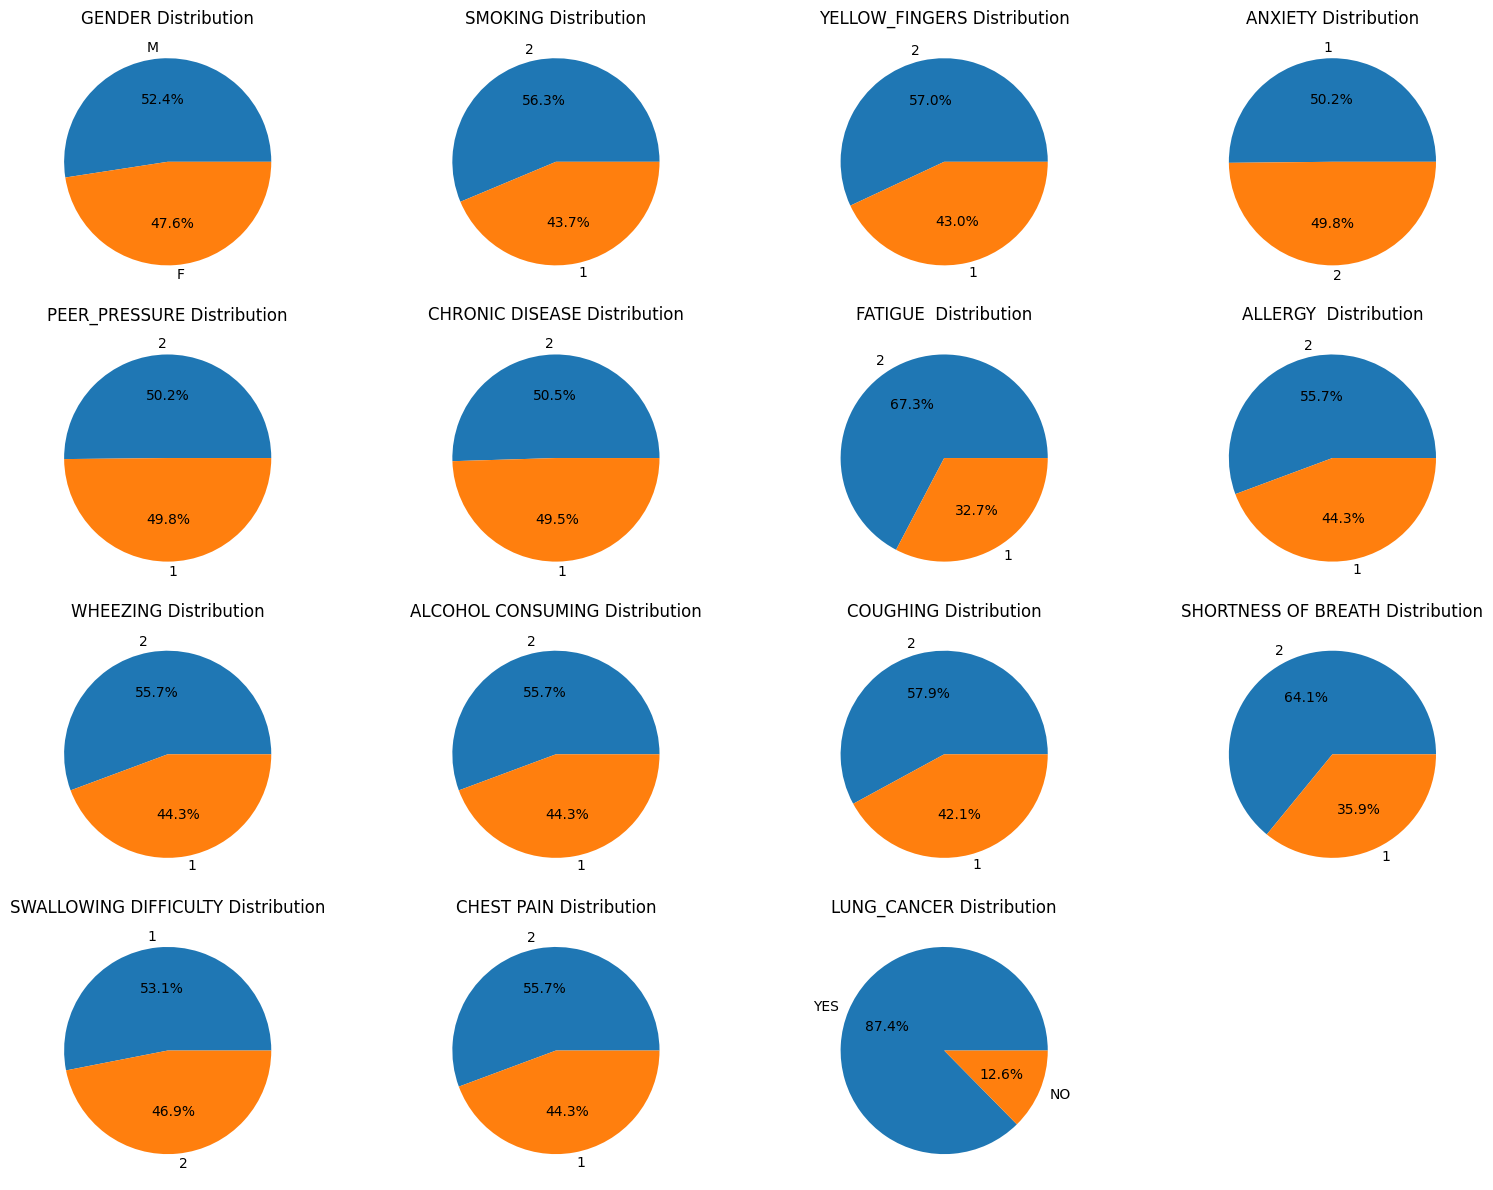

In [13]:
df_columns = ['GENDER', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING',
       'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH',
       'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']

n_cols = 4  # number of columns in subplot grid
n_rows = math.ceil(len(df_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
axes = axes.flatten()  # make indexing easier

for i, col in enumerate(df_columns):
    value_counts = df[col].value_counts()
    
    axes[i].pie(
        value_counts,
        labels=value_counts.index,
        autopct='%1.1f%%'
    )
    axes[i].set_title(f"{col} Distribution")

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

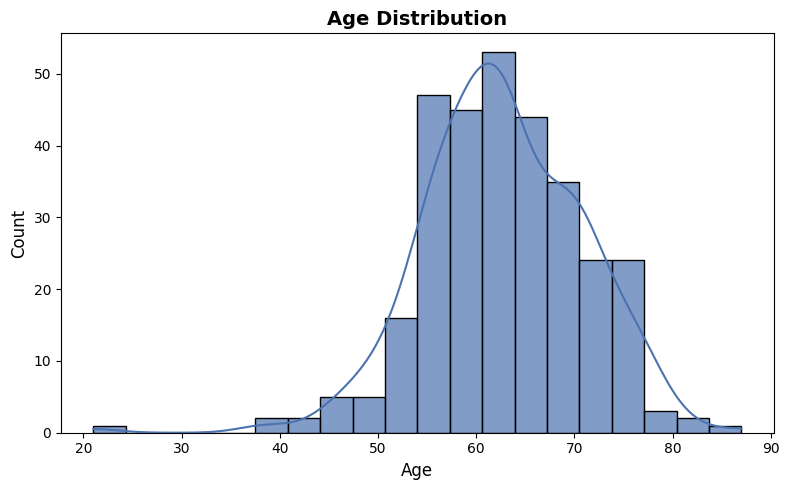

In [14]:
# Age distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="AGE",
    bins=20,
    kde=True,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.7
)

plt.title("Age Distribution", fontsize=14, weight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

### Data Preparation
We will:
1. Mapping GENDER and LUNG_CANCER column to numerical features
2. Feature Selection
3. Data splitting (X,y, and train test split)
4. Standardization using StandardScaler (important for LogReg and GaussianNB)

In [20]:
# confirm the data type is wrong
print(f"Data type of GENDER column: {df["GENDER"].dtype}")
print(f"Unique values of GENDER column: {df["GENDER"].unique()}\n")
print(f"Data type of LUNG_CANCER column: {df['LUNG_CANCER'].dtype}")
print(f"Unique values of LUNG_CANCER column: {df["LUNG_CANCER"].unique()}")

# Encoding
df_encoded = pd.get_dummies(df, columns= ["GENDER"])
df_encoded["LUNG_CANCER"] = df["LUNG_CANCER"].map({"YES" : 1, "NO" : 0})
df_encoded.rename(columns={"GENDER_M" : "MALE", "GENDER_F" : "FEMALE", "YELLOW_FINGERS" : "YELLOW FINGERS", "PEER_PRESSURE" : "PEER PRESSURE", "LUNG_CANCER" : "LUNG CANCER", "FATIGUE " : "FATIGUE", "ALLERGY " : "ALLERGY", "SWALLOWING_DIFFICULTY" : "SWALLOWING DIFFICULTY", "ALCOHOL_CONSUMING" : "ALCOHOL CONSUMING", "CHEST_PAIN" : "CHEST PAIN", "SHORTNESS_OF_BREATH" : "SHORTNESS OF BREATH", "CHRONIC_DISEASE" : "CHRONIC DISEASE"}, inplace=True)
df_encoded = df_encoded[["AGE","MALE","FEMALE","ALCOHOL CONSUMING","CHEST PAIN","SHORTNESS OF BREATH","COUGHING","PEER PRESSURE","CHRONIC DISEASE","SWALLOWING DIFFICULTY","YELLOW FINGERS","ANXIETY","FATIGUE","ALLERGY","WHEEZING","LUNG CANCER"]]

# Remove duplicate
df_clean = df_encoded.drop_duplicates()

# Check the dataset to confirm if the mapping is successful
df_clean.info()

Data type of GENDER column: str
Unique values of GENDER column: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str

Data type of LUNG_CANCER column: str
Unique values of LUNG_CANCER column: <ArrowStringArray>
['YES', 'NO']
Length: 2, dtype: str
<class 'pandas.DataFrame'>
Index: 275 entries, 0 to 283
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   AGE                    275 non-null    int64
 1   MALE                   275 non-null    bool 
 2   FEMALE                 275 non-null    bool 
 3   ALCOHOL CONSUMING      275 non-null    int64
 4   CHEST PAIN             275 non-null    int64
 5   SHORTNESS OF BREATH    275 non-null    int64
 6   COUGHING               275 non-null    int64
 7   PEER PRESSURE          275 non-null    int64
 8   CHRONIC DISEASE        275 non-null    int64
 9   SWALLOWING DIFFICULTY  275 non-null    int64
 10  YELLOW FINGERS         275 non-null    int64
 11  ANXIETY   

In [21]:
df_clean.head()

,AGE,MALE,FEMALE,ALCOHOL CONSUMING,CHEST PAIN,SHORTNESS OF BREATH,COUGHING,PEER PRESSURE,CHRONIC DISEASE,SWALLOWING DIFFICULTY,YELLOW FINGERS,ANXIETY,FATIGUE,ALLERGY,WHEEZING,LUNG CANCER
0,69,True,False,2,2,2,2,1,1,2,2,2,2,1,2,1
1,74,True,False,1,2,2,1,1,2,2,1,1,2,2,1,1
2,59,False,True,1,2,2,2,2,1,1,1,1,2,1,2,0
3,63,True,False,2,2,1,1,1,1,2,2,2,1,1,1,0
4,63,False,True,1,1,2,2,1,1,1,2,1,1,1,2,0


<Axes: >

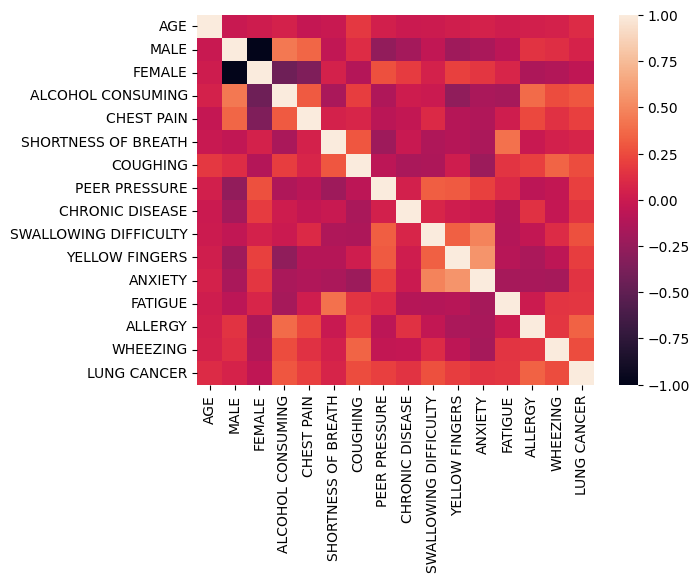

In [22]:
# Feature selection
df_corr = df_clean.corr()
sns.heatmap(df_corr)

All feature have low correlation, so we can't use correlation matrix to do feature selection. Instead, we will use RandomForestClassifier faeture importance to do the feature selection. But before that, we need to split the Data to X and Y first.The correlation analysis shows that all features have low pairwise correlation, indicating weak linear relationships between variables and no significant redundancy. As a result, the correlation matrix is not suitable for feature selection in this case.

Since no features appear strongly correlated or redundant, all features are retained for model training to preserve as much information as possible. The dataset is then split into input features (X) and the target variable (y) before proceeding with modeling.

In [23]:
# Ambil sample 30%
# df_sample = df_clean.sample(frac=0.1, random_state=42)

# Data splitting
X = df_clean.drop("LUNG CANCER", axis=1)
y = df_clean['LUNG CANCER']
# x, y = make_classification(n_samples=100000, n_features=100, random_state=42)

# Scaler and spliting
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Shape of training data : {x_train.shape}, {y_train.shape}")
print(f"Shape of testing data : {x_test.shape}, {y_test.shape}")

Shape of training data : (220, 15), (220,)
Shape of testing data : (55, 15), (55,)


### Modeling
Default Param

In [26]:
# LOGREG
logreg = LogisticRegression()
logreg.fit(x_train_scaled, y_train)
y_pred = logreg.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.70      0.78        10
           1       0.94      0.98      0.96        45

    accuracy                           0.93        55
   macro avg       0.91      0.84      0.87        55
weighted avg       0.93      0.93      0.92        55

